# 1. Point clouds and I/O

`sylva.PointCloud` is an `(N, 3)` float64 array plus named per-point attributes.
It is what readers return and what almost every function takes.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import sylva
from sylva import synthetic

DATA = Path("data")          # the Litchfield tile, cut by make_litch_subset.py
plt.rcParams.update({"figure.dpi": 90, "figure.figsize": (7, 4), "axes.grid": False})

The data: a 20 x 20 m tile of the TERN [Litchfield Savanna
SuperSite](https://www.tern.org.au) plot in the Northern Territory, scanned in
2021 with a RIEGL VZ-2000i from many positions and registered into one cloud.
`litch_tile.laz` holds the echoes inside the tile thinned to 5 cm, with
`classification` (2 ground, 4 vegetation) and `intensity`;
`litch_tile_shots.parquet` holds every 40th pulse, clipped to the tile, misses
included. The plot data are TERN's; `make_litch_subset.py` cuts the tile.

In [2]:
cloud = sylva.read(DATA / "litch_tile.laz")
print(cloud)
lo, hi = cloud.bounds
print("extent:", np.round(hi - lo, 2), "m")
{k: (v.dtype, v.min(), v.max()) for k, v in cloud.attrs.items()}

PointCloud(n=1,553,677, attrs=['classification', 'gps_time', 'intensity', 'number_of_returns', 'point_source_id', 'return_number', 'scan_angle', 'user_data'])
extent: [20.   20.   20.17] m


{'classification': (dtype('uint8'), np.uint8(2), np.uint8(4)),
 'gps_time': (dtype('float64'), np.float64(0.0), np.float64(0.0)),
 'intensity': (dtype('uint16'), np.uint16(95), np.uint16(241)),
 'number_of_returns': (dtype('uint8'), np.uint8(0), np.uint8(0)),
 'point_source_id': (dtype('uint16'), np.uint16(0), np.uint16(0)),
 'return_number': (dtype('uint8'), np.uint8(0), np.uint8(0)),
 'scan_angle': (dtype('float32'), np.float32(0.0), np.float32(0.0)),
 'user_data': (dtype('uint8'), np.uint8(0), np.uint8(0))}

LAS files bring their standard dimensions along, whether or not the data
filled them in: `return_number` and `scan_angle` here are artefacts of the
export, while `classification` and `intensity` carry real information. Indexing
with a mask, indices or a slice keeps every attribute aligned, and `with_attrs`
returns a copy with extra columns.

In [3]:
veg = cloud[cloud.attrs["classification"] == 4]
ground_pts = cloud[cloud.attrs["classification"] == 2]
cloud = cloud.with_attrs(range=np.linalg.norm(cloud.xyz - [10, 10, 1.5], axis=1).astype(np.float32))
print(veg, ground_pts, sep="\n")
print("vegetation:", f"{len(veg) / len(cloud):.0%} of the tile")

PointCloud(n=1,376,604, attrs=['classification', 'gps_time', 'intensity', 'number_of_returns', 'point_source_id', 'return_number', 'scan_angle', 'user_data'])
PointCloud(n=177,073, attrs=['classification', 'gps_time', 'intensity', 'number_of_returns', 'point_source_id', 'return_number', 'scan_angle', 'user_data'])
vegetation: 89% of the tile


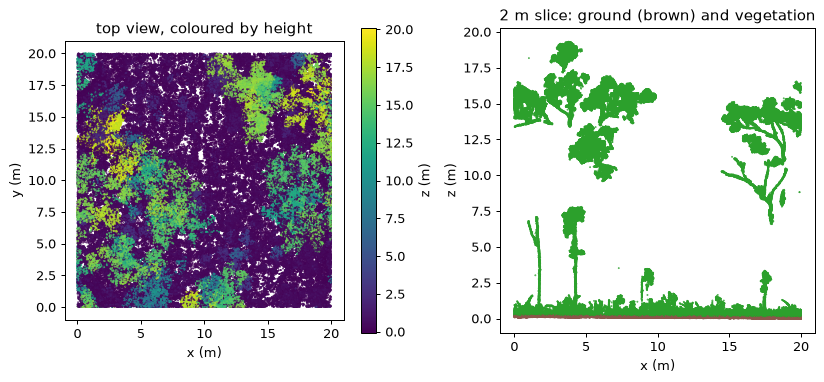

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.4))
s = ax[0].scatter(cloud.x[::4], cloud.y[::4], c=cloud.z[::4], s=0.2, cmap="viridis")
ax[0].set(title="top view, coloured by height", xlabel="x (m)", ylabel="y (m)", aspect="equal")
fig.colorbar(s, ax=ax[0], label="z (m)")
slab = (cloud.y > 9) & (cloud.y < 11)
ax[1].scatter(cloud.x[slab], cloud.z[slab], s=0.2,
              c=np.where(cloud.attrs["classification"][slab] == 2, "tab:brown", "tab:green"))
ax[1].set(title="2 m slice: ground (brown) and vegetation", xlabel="x (m)", ylabel="z (m)", aspect="equal");

## Reading and writing

`sylva.read` / `sylva.write` pick the format from the extension: LAS/LAZ (extra
attributes become typed extra-bytes dimensions), PLY, and delimited text.
RIEGL `.rxp` needs RiVLib, see `sylva.io.read_rxp`. This tile came from a
raycloudtools ray cloud, which `read` also opens -- `nx, ny, nz` then point
from each echo back to the scanner (notebook 8).

In [5]:
import tempfile
tmp = Path(tempfile.mkdtemp())
small = cloud[::20]
for name in ("tile.laz", "tile.ply", "tile.csv"):
    sylva.write(small, tmp / name)
    back = sylva.read(tmp / name)
    print(f"{name:9s} {(tmp / name).stat().st_size / 1e6:6.2f} MB  {len(back):,} points  attrs: {sorted(back.attrs)}")

tile.laz    0.61 MB  77,684 points  attrs: ['classification', 'gps_time', 'intensity', 'number_of_returns', 'point_source_id', 'range', 'return_number', 'scan_angle', 'user_data']
tile.ply    3.73 MB  77,684 points  attrs: ['classification', 'gps_time', 'intensity', 'number_of_returns', 'point_source_id', 'range', 'return_number', 'scan_angle', 'user_data']
tile.csv    4.57 MB  77,684 points  attrs: ['classification', 'gps_time', 'intensity', 'number_of_returns', 'point_source_id', 'range', 'return_number', 'scan_angle', 'user_data']


In [6]:
laz = sylva.read(tmp / "tile.laz")
print("max coordinate error after LAZ (1 mm scale):", np.abs(laz.xyz - small.xyz).max())
print("classification dtype preserved:", laz.attrs["classification"].dtype,
      " range attribute:", laz.attrs["range"].dtype)

max coordinate error after LAZ (1 mm scale): 0.0
classification dtype preserved: uint8  range attribute: float32


Plain arrays come in through `PointCloud.from_array`, naming the columns after x, y, z.

In [7]:
arr = np.column_stack([cloud.xyz, cloud.attrs["classification"]])
sylva.PointCloud.from_array(arr, names={3: "classification"})

PointCloud(n=1,553,677, attrs=['classification'])